# Chapter 1 and 2

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

## Setting the Framework:

Instead of requiring humans to manually derive rules and build models from analyzing large amounts of data, machine learning offers a more efficient alternative for capturing the knowledge in data to gradually improve the performance of predictive models. There are 3 fundalmental kind of Machine Learning:
- Supervised learning: The training set is labeled, and the ML model is tested against other labeled data which it has not been trained on. 
    - Multiclass Classification: The point is to label new data into distinct categories. For example, a ML model might label a handwriting as either any integer from 0-9.
    - Regression Analysis: Unlike classification where there are distinct categories, regressions deal with continuous value. Given known value of x, what is the predicted value of y?
- Unsupervised learning: The data is unlabeled. Using unsupervised learning, we can extract meaningful information from unknown structure of data without any guidance.
    - Clustering: organize a pile of information into meaningful subgroups (clusters) without having any prior knowledge of their group memberships. 
    - Dimensionality reduction: We often work in very high dimensional data set. Dimensionality reduction compresses the data onto a smaller dimensional subspace while retaining most of the relevant information. 
- Reinforcement learning: The goal is to develop a system (agent) that improves its performance based on interactions with the environment. We assign some "reward signals," where the goal of the ML is to maximize this reward. 



## Artifical Neurons:

Lets define $x=\{x_1,x_2,...,x_m\}$. This is the input/features for each Perceptron. Each input also has a weight, w, which is define as $w=\{w_1,w_2,...,w_m\}$.
We then define $z=x\cdot w$. Each Perceptron will then take this as input, and use $\sigma(z)$ to decide the value to pass to further Perceptron. A simple $\sigma$ is define as:
$$
\sigma(z) =
\begin{cases}
1 & \text{if } z \geq \theta \\
0 & \text{otherwise}
\end{cases}
$$

Where $\theta$ is our activation threshold. As per convention, we define $b=-\theta$ and $z=x\cdot w + b$. Thus:
$$
\sigma(z) =
\begin{cases}
1 & \text{if } z \geq 0 \\
0 & \text{otherwise}
\end{cases}
$$

A simple way to train this algorithm is to start with an initial $b$ and $w$ value, and for each training set $x^{(i)}$, we update the weight and bias.

$$
w_{j} \leftarrow w_j + \Delta w_j
\\
b \leftarrow b + \Delta b
$$
Where:
$$
\Delta w_j = \eta(y^{(i)} - \hat{y}^{(i)})x^{(i)}_j\\ \Delta b=\eta(y^{(i)} - \hat{y}^{(i)})$$

Where each $y^{(i)} \in y$ is the true label, $\eta \in [0,1]$ is the learning rate, and $\hat{y}$ is predicted output. The outline of Perceptrons is below.

This can be written compactly as:
$$
w \leftarrow w + \Delta w_j \\
\Delta w = \eta (y^{(i)} - \hat{y}^{(i)})x^{i}
$$

<div align="center">
  <img src="Medias/Perceptron.png" width="600">
</div>

In [28]:
#Download Dataset from UCI ML repo; Iris
%pip install ucimlrepo

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [29]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
iris = fetch_ucirepo(id=53) 
  
# data (as pandas dataframes) 
X = iris.data.features 
y = iris.data.targets 

print(X) 
print(y)

#Turn it into numpy array/matrix
X = X.values
y = y.values


     sepal length  sepal width  petal length  petal width
0             5.1          3.5           1.4          0.2
1             4.9          3.0           1.4          0.2
2             4.7          3.2           1.3          0.2
3             4.6          3.1           1.5          0.2
4             5.0          3.6           1.4          0.2
..            ...          ...           ...          ...
145           6.7          3.0           5.2          2.3
146           6.3          2.5           5.0          1.9
147           6.5          3.0           5.2          2.0
148           6.2          3.4           5.4          2.3
149           5.9          3.0           5.1          1.8

[150 rows x 4 columns]
              class
0       Iris-setosa
1       Iris-setosa
2       Iris-setosa
3       Iris-setosa
4       Iris-setosa
..              ...
145  Iris-virginica
146  Iris-virginica
147  Iris-virginica
148  Iris-virginica
149  Iris-virginica

[150 rows x 1 columns]


In [30]:
class Perceptron: #We append an underscore _ to attributes that are not created upon the initialization of the object
    
    def __init__(self,eta = 0.2, n_iter = 50, random_state = 1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def net_input(self, x): #Our net value function
        return np.dot(x, self.w_) + self.b_

    def predict(self, x): #Whether or not it is 1 or 0
        if self.net_input(x)>=0:
            return 1
        else:
            return 0
    
    def fit(self, X, y):
        ran = np.random.RandomState(self.random_state)
        self.w_ = ran.normal(loc=0.0, scale=0.1, size=X.shape[1]) #Gives random weighs
        self.b_ = np.float64(0.) #Bias is set at 0
        self.errors_ = []
        
        for _ in range(self.n_iter):
            errors = 0
            for xi, yi in zip(X, y):
                update = self.eta * (yi - self.predict(xi))
                self.w_ += update * xi
                self.b_ += update
                errors += int(update != 0.0)
            self.errors_.append(errors)
        return self

In [31]:
#change y so that its 1 or 0
#Iris-setosa is 1
y = np.array([int(n=='Iris-setosa') for n in y])
Xtrain = X[0:100:4]
ytrain = y[0:100:4]

Xpred = X[1:100:4]
ypred = y[1:100:4]

ML = Perceptron(eta = 0.1, n_iter = Xtrain.shape[0], random_state = 1)
ML.fit(Xtrain,ytrain)



pred = np.array([])
for i,j in zip(Xpred,ypred):
    pred = np.append(pred, ML.predict(i))
pred = pred.astype(int)

print(pred) #prediction by the Perceptron
print(ypred) #actual true label

[1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
[1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]


/var/folders/ct/9zkf8cxd2pn8hv1p2w8_z_6r0000gn/T/ipykernel_61800/3801606091.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y = np.array([int(n=='Iris-setosa') for n in y])


Lets examine the Perceptron and our data set more closely. We will use several graphs:

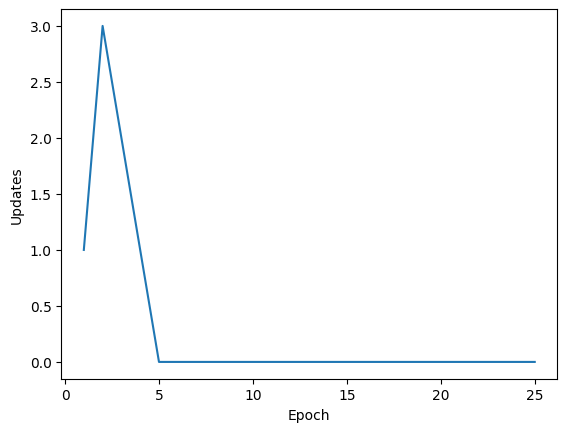

In [32]:
plt.plot(range(1, len(ML.errors_)+1),ML.errors_)
plt.xlabel("Epoch")
plt.ylabel("Updates")
plt.show()

We see from the code above that our Perceptron model converges to 0.

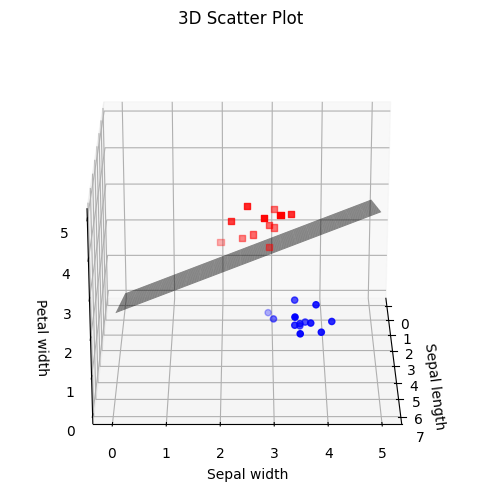

In [33]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# scatter plot
ax.scatter(Xtrain[:13,0], Xtrain[:13,1], Xtrain[:13,2], c='blue', marker='o')
ax.scatter(Xtrain[13:,0], Xtrain[13:,1], Xtrain[13:,2], c='red', marker='s')
# labels
ax.set_xlabel("Sepal length")
ax.set_ylabel("Sepal width")
ax.set_zlabel("Petal width")
ax.set_title("3D Scatter Plot")


#Create dividing planes
a,b,c = ML.w_[0:3]

x, y = np.meshgrid(np.linspace(0, 5, 20), np.linspace(0, 5, 20))

z = -(a*x + b*y + ML.b_)/c #This is derive from f(x) = w*x + b. We set f(x) = 0 because it is the boudary; anything above is 

ax.plot_surface(x, y, z, alpha=0.5, color="black")


ax.view_init(elev=23, azim=0)


## Adaptive Linear Neurons

To improve upon the perceptron, we input simply change $\sigma(z)=z$, and create a new function, like the original step function, to make 
the decision of whether our prediction is 0 or 1. Note that our step function now requires it to be equal or above 0.5 to be 1, and 0 otherwise.

<div align="center">
  <img src="Medias/Adaline.png" width="600">
</div>

When we do this, we make $\sigma$ differentiable, which means we can introduce a loss function $L$ to minimize:
$$
L(w,b) = \frac{1}{2N} \sum_{i=1}^{N} (y^{(i)} - \sigma(z^{(i)}))^2
$$
Where $z^{(i)}= w\cdot x^{i} + b$, and $y_i$ is the true label.


Because this function is also continuous, we can find the Gradient of it.
$$
\nabla L = \left(\frac{\partial L}{\partial w_1}, \frac{\partial L}{\partial w_2}, ..., \frac{\partial L}{\partial w_n}, \frac{\partial L}{\partial b} \right)
$$
Lets compute it for each $w_j$ then
$$
\frac{\partial L}{\partial w_j} = \frac{1}{N} \sum_{i=1}^{N} (y^{(i)} - \sigma(z^{(i)})) \frac{\partial}{\partial w_j} (-z^{(i)}) \\[1em]
\frac{\partial}{\partial w_j} (-z^{(i)}) = -\sum_{m=1}^n w_m x^{(i)}_m + b \\[1em]
\frac{\partial}{\partial w_j} (-z^{(i)}) =- \frac{\partial}{\partial w_j} w_j x_j^{(i)} = -x_j^{(i)}
$$

Note that in the second summation indexed by m, the partial derivative turns every term where $m\neq j$ to 0, leaving only $w_jx_j^{(i)}$. Thus our final derivative is:
$$
\boxed{\frac{\partial L}{\partial w_j} = -\frac{1}{N} \sum_{i=1}^{N} (y^{(i)} - \sigma(z^{(i)}) \ )x_j^{(i)}}
$$

With similar logic, we find that:
$$
\boxed{\frac{\partial L}{\partial b} = -\frac{1}{N} \sum_{i=1}^{N} (y^{(i)} - \sigma(z^{(i)}) \ )}
$$

We can then change our updating rule with the following:
$$
\boxed{
\begin{aligned}
w_{j} &\leftarrow w_j - \eta \frac{\partial L}{\partial w_j} \Bigg|_{w,b} \\[1em]
b &\leftarrow b - \eta \frac{\partial L}{\partial b} \Bigg|_{w,b}
\end{aligned}
}
$$

We will call this Full Batch Gradient Descent (FBGD). Lets implement it:

In [34]:
class AdalineGD:
    
    def __init__(self,eta = 0.2, n_iter = 50, random_state = 1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    #We append an underscore _ to attributes that are not created upon the initialization of the object
    
    def net_input(self, x): #Our net value function
        return np.dot(x, self.w_) + self.b_

    def activation(self, x):
        return x

    def predict(self, x): #Whether or not it is 1 or 0
        if self.net_input(x)>=0.5:
            return 1
        else:
            return 0
    
    
    def fit(self, X, y):
        #Define weigh, bias, and keep track of loss
        ran = np.random.RandomState(self.random_state)
        self.w_ = ran.normal(loc=0.0, scale=0.2, size=X.shape[1])
        self.b_ = np.float64(0.)
        self.loss = []

        for epoch in range(self.n_iter):
            output = self.activation(self.net_input(X)) #Even though X is matrix, each vector in x is computed piecewise; type = 1D array
            error = (y - output) #array

            #Update Value
            grad_w = -X.T.dot(error) / X.shape[0] #Neat little trick
            grad_b = -error.mean()

            self.w_ -= self.eta * grad_w
            self.b_ -= self.eta * grad_b

            # Track loss function over epoch
            self.loss.append((error**2).mean()/2)

        return self


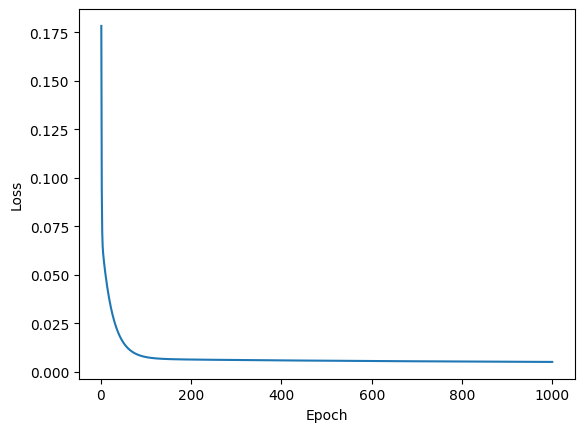

Final Loss: 0.0051050579668019515
First time below 0.01:  71


In [128]:
Adaline = AdalineGD(eta = 0.01, n_iter =1000, random_state = 1)
Adaline.fit(Xtrain,ytrain)

plt.plot(range(1, Adaline.n_iter+1),Adaline.loss)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

loss = np.array(Adaline.loss)
print(f"Final Loss: {Adaline.loss[Adaline.n_iter -1]}")
loss = (loss < 0.01)
print("First time below 0.01: ", np.where(loss == True)[0][0])

We see from our implementation above that we are very successful at minimizing our loss function.

## Feature Scaling

To help our ML model learn faster, we scale our features accordingly. We will most notably use Standardization:
$$
x_j' = \frac{x_j - \mu_j}{\sigma_j}
$$

Where $\mu_j$ is the mean of that feature and $\sigma_j$ is the standard deivation of that feature.

Standardization helps help to find a learning rate that works well for all weights and bias. If the features are on different scales, a learning rate that works well for updating one weight might be too large or too small to update the other weight. Lets test it out:

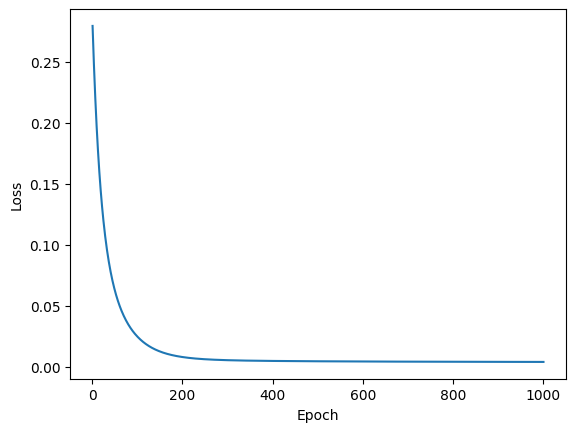

Final Loss: 0.003772459925064548
First time below 0.01:  170


In [109]:
Xstd = np.copy(Xtrain)
Xstd[:,0] = (Xtrain[:,0] - Xtrain[:,0].mean()) / Xtrain[:,0].std()
Xstd[:,1] = (Xtrain[:,1] - Xtrain[:,1].mean()) / Xtrain[:,1].std()
Xstd[:,2] = (Xtrain[:,2] - Xtrain[:,2].mean()) / Xtrain[:,2].std()
Xstd[:,3] = (Xtrain[:,3] - Xtrain[:,3].mean()) / Xtrain[:,3].std()

Adaline = AdalineGD(eta = 0.01, n_iter =1000, random_state = 1)
Adaline.fit(Xstd,ytrain)

plt.plot(range(1, Adaline.n_iter+1),Adaline.loss)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

loss = np.array(Adaline.loss)
print(f"Final Loss: {Adaline.loss[999]}")
loss = (loss < 0.01)
print("First time below 0.01: ", np.where(loss == True)[0][0])

We see that it is slightly better compare to our unstandardize features.

## Stochastic Gradient Descent

In FBGD, we compute our loss function by taking the entire training dataset for each iteration/epoch. For every large ML however, this may not be very resourceful. We thus have the SGD to help, which works by changing how our weighs and bias changes to the following:
$$
w_j \leftarrow w_j - \eta_{iter} \Delta w_j \\
b \leftarrow b - \eta_{iter} \Delta b \\
$$

Where
$$\Delta w_j = (y^{(i)}-\sigma(z^{(i)})) x^{(i)}_j \\ 
\Delta b = (y^{(i)}-\sigma(z^{(i)})) $$. Notice how in this version we do not sum over the entire training set. Instead, we randomly choose "i" in this case. Also note that the reason by $\eta_{iter}$ is subscripted is because with every iteration it decreases, and may look something like:
$$
\eta_{iter} = \frac{C_1}{\text{iteration} + C_2}
$$

Implementing SGD is fairly simple because we do not need to change alot from earlier: $\\$

In [83]:
class SGD(AdalineGD):

    def initialize_weights(self, m):
        """Initialize weights to small random numbers"""
        self.rgen = np.random.RandomState(self.random_state)
        self.w_ = self.rgen.normal(loc=0.0, scale=0.05, size=m)
        self.b_ = np.float64(0.)
        self.w_initialized = True

    def shuffle(self, X, y): #Return shuffled data set
        r = self.rgen.permutation(len(y))
        return X[r], y[r]
    
    def update(self, xi, yi):
        output = super().activation(super().net_input(xi))
        error = (yi - output)
        self.w_ += self.eta * xi * (error)
        self.b_ += self.eta * error
        return error**2

        #loss function

    def fit(self,X,y):
        self.initialize_weights(X.shape[1])
        self.loss = []
        for epoch in range(self.n_iter):
            self.eta = (0.01)/(0.5 + epoch/3)
            X,y = self.shuffle(X,y)
            tempLoss = []
            for xi,yi in zip(X,y):
                tempLoss.append(self.update(xi,yi))
            self.loss.append(np.mean(tempLoss))
        return self
    
    def partial_fit(self, X, y):
        """Fit training data with new ones without reinitializing the weights"""
        if y.ravel().shape[0] > 1:
            for xi, yi in zip(X, y):
                self.update(xi, yi)
        else:
            self.update(X, y)
        return self

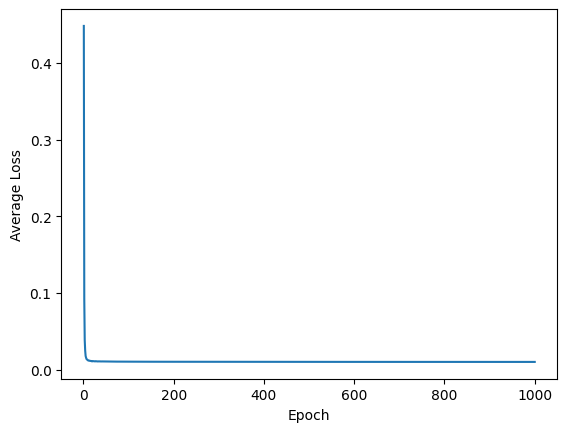

Final Average Loss: 0.009941517899882023
 
 Prediction Vs Actual label:
[1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
[1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
First time below 0.01:  563


In [130]:
SGDmodel = SGD(n_iter = 1000, random_state = 5)
SGDmodel.fit(Xtrain,ytrain)

plt.plot(range(1, SGDmodel.n_iter+1),SGDmodel.loss)
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.show()
print(f"Final Average Loss: {SGDmodel.loss[SGDmodel.n_iter-1]}")

pred = np.array([])

for xi in Xpred:
    input = SGDmodel.predict(xi)
    pred = np.append(pred, input)

pred = pred.astype(int)
print(" \n Prediction Vs Actual label:")
print(pred) #prediction by the Perceptron
print(ypred) #actual true label

loss = np.array(SGDmodel.loss)
loss = (loss < 0.01)
if (SGDmodel.loss[SGDmodel.n_iter-1] <= 0.01):
    print("First time below 0.01: ", np.where(loss == True)[0][0])

It took us 10 iterations to get around 0.01 in Loss. That concludes Chapter 1-2 of this note.